Loading data from: ../artifacts

✅ aparat: 1075 real bursts loaded
✅ filimo: 727 real bursts loaded

GENERATING INDIVIDUAL FEATURE FIGURES

Saved: ../comparison_figures/fig_3a_bytes_comparison_downlink.pdf
Saved: ../comparison_figures/fig_3a_bytes_comparison_downlink.png


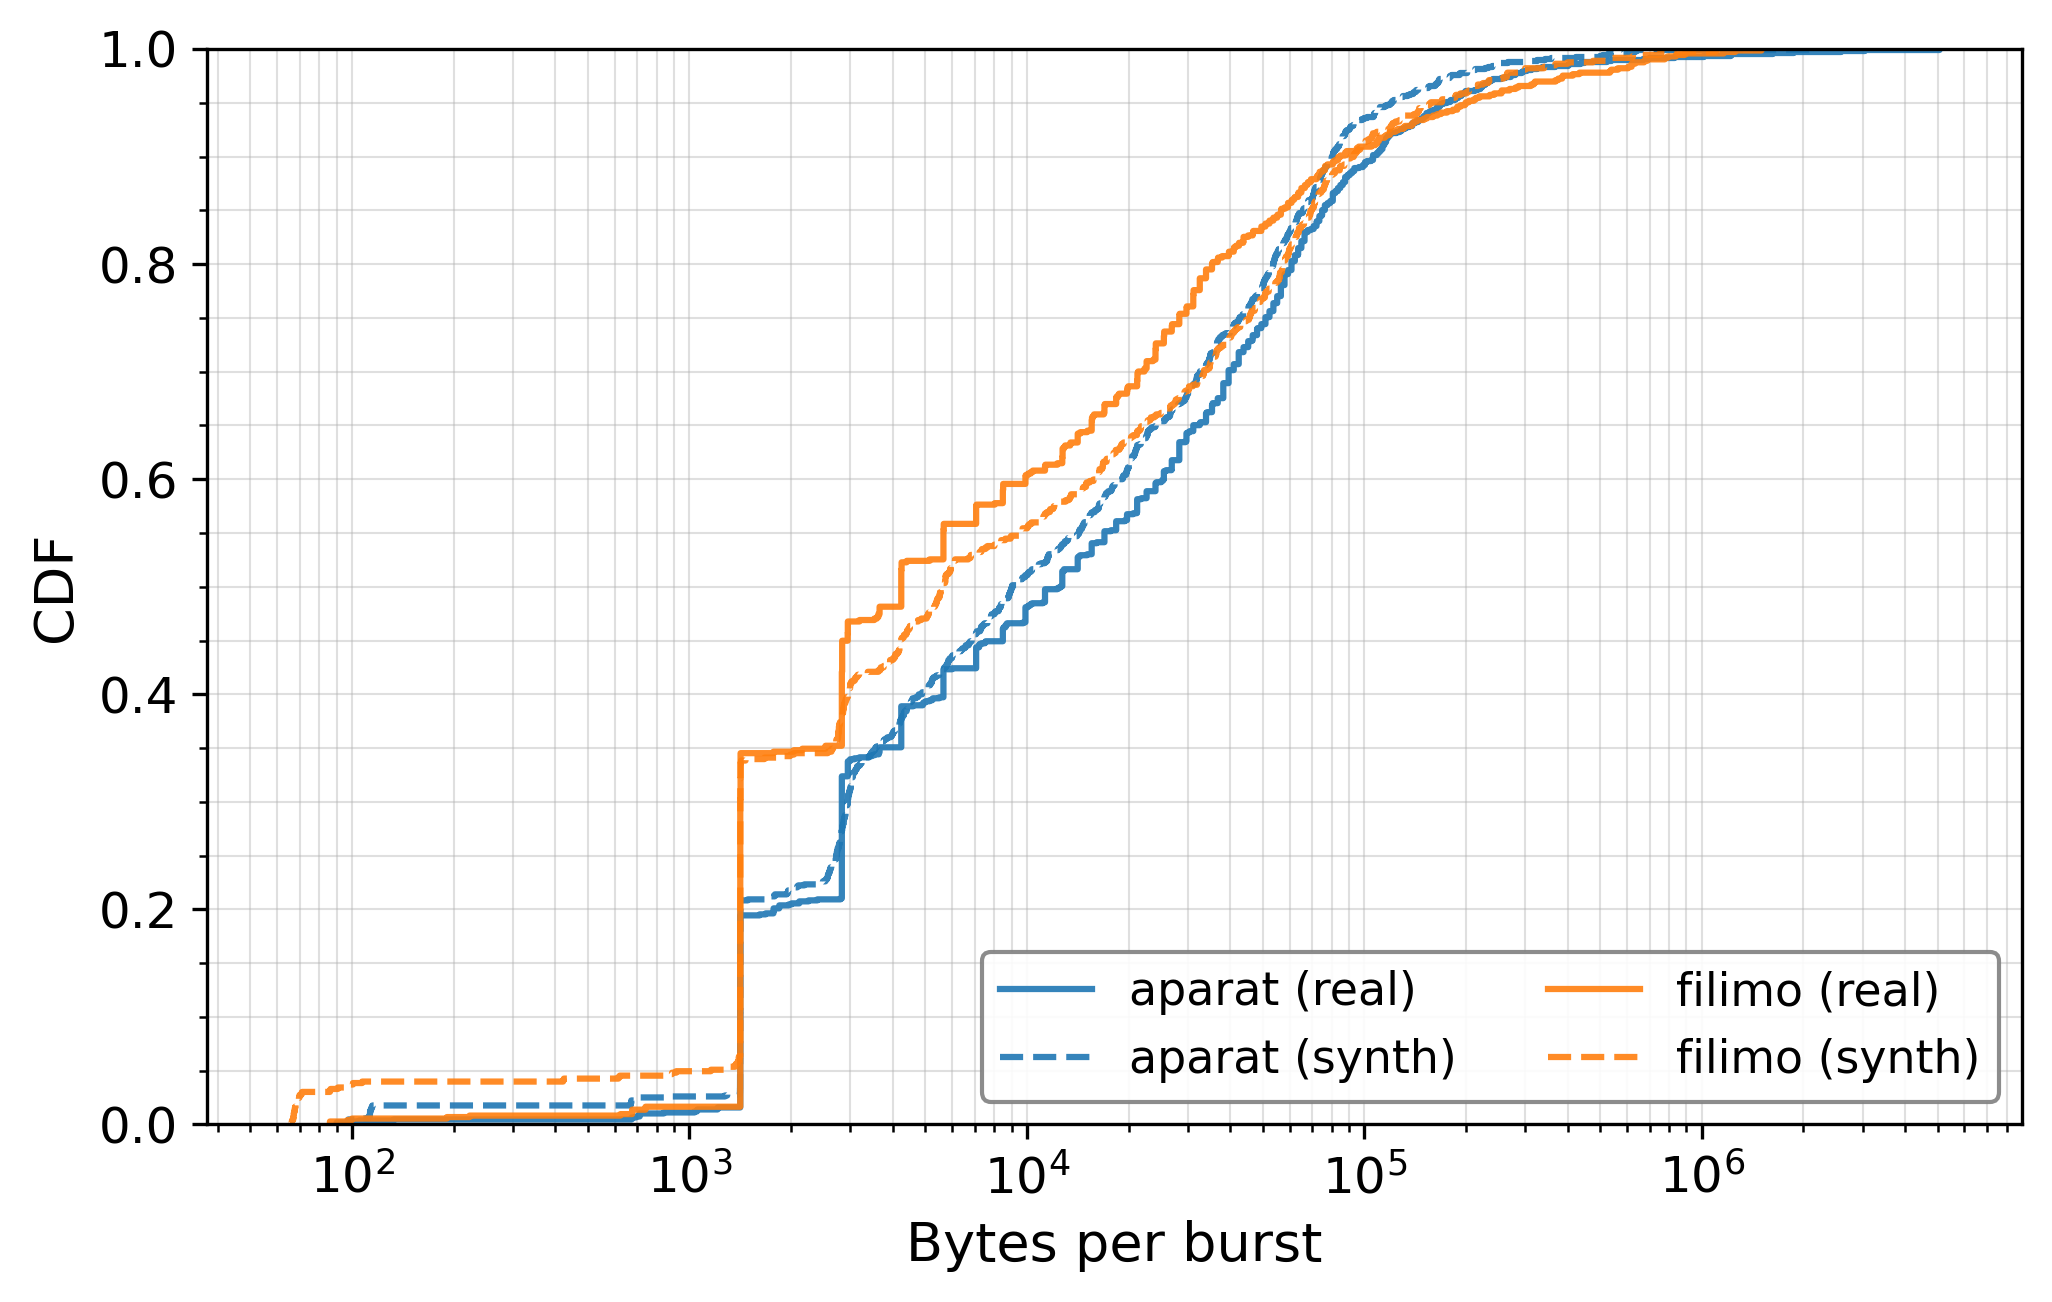

Saved: ../comparison_figures/fig_3b_off_duration_comparison_downlink.pdf
Saved: ../comparison_figures/fig_3b_off_duration_comparison_downlink.png


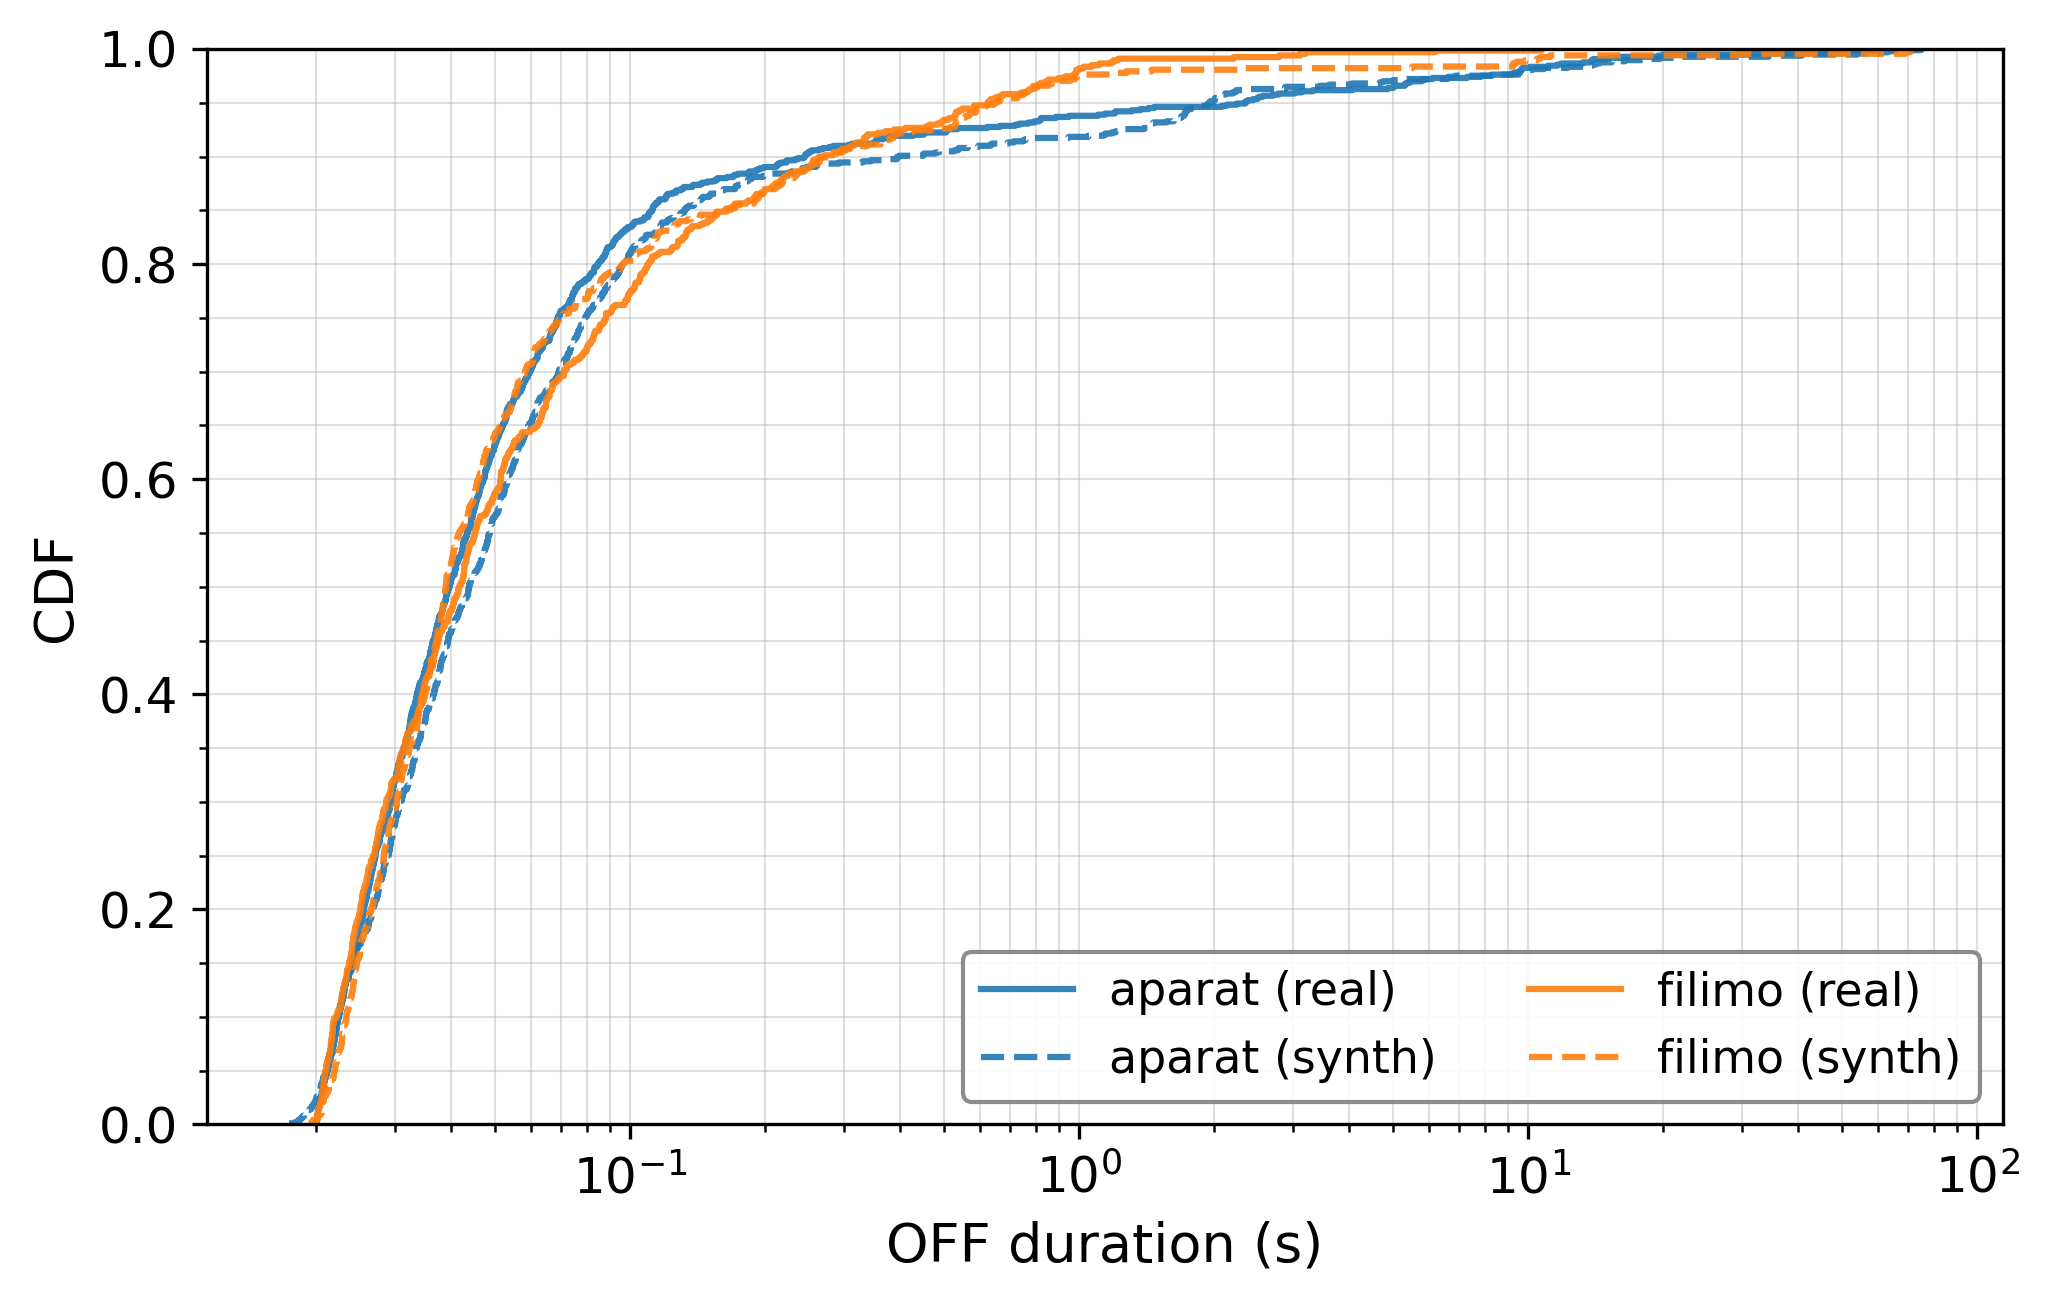

Saved: ../comparison_figures/fig_3c_on_duration_comparison_downlink.pdf
Saved: ../comparison_figures/fig_3c_on_duration_comparison_downlink.png


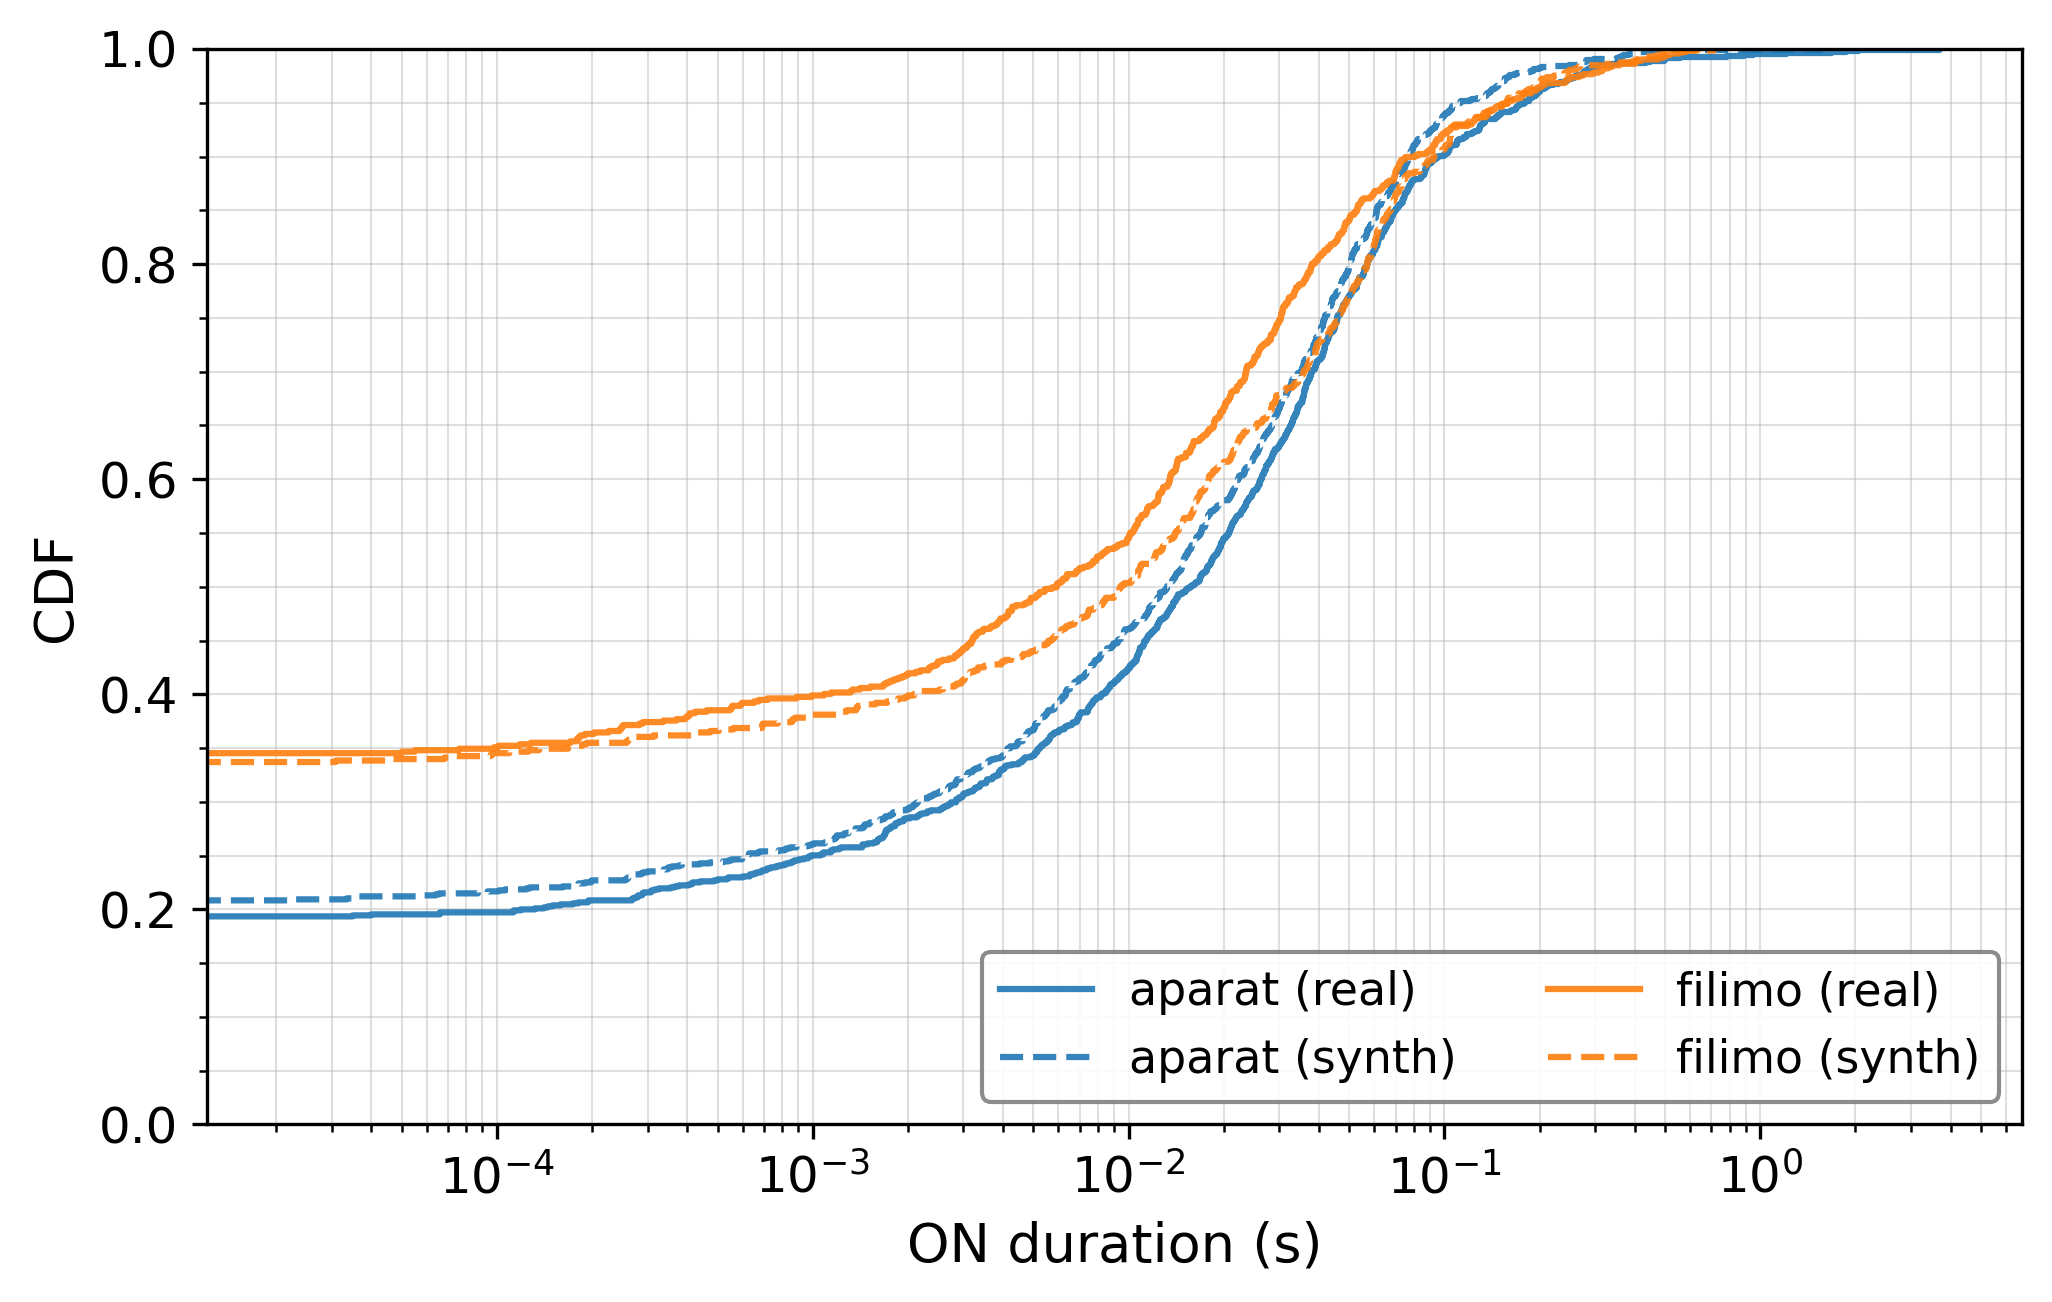

Saved: ../comparison_figures/fig_3d_packets_comparison_downlink.pdf
Saved: ../comparison_figures/fig_3d_packets_comparison_downlink.png


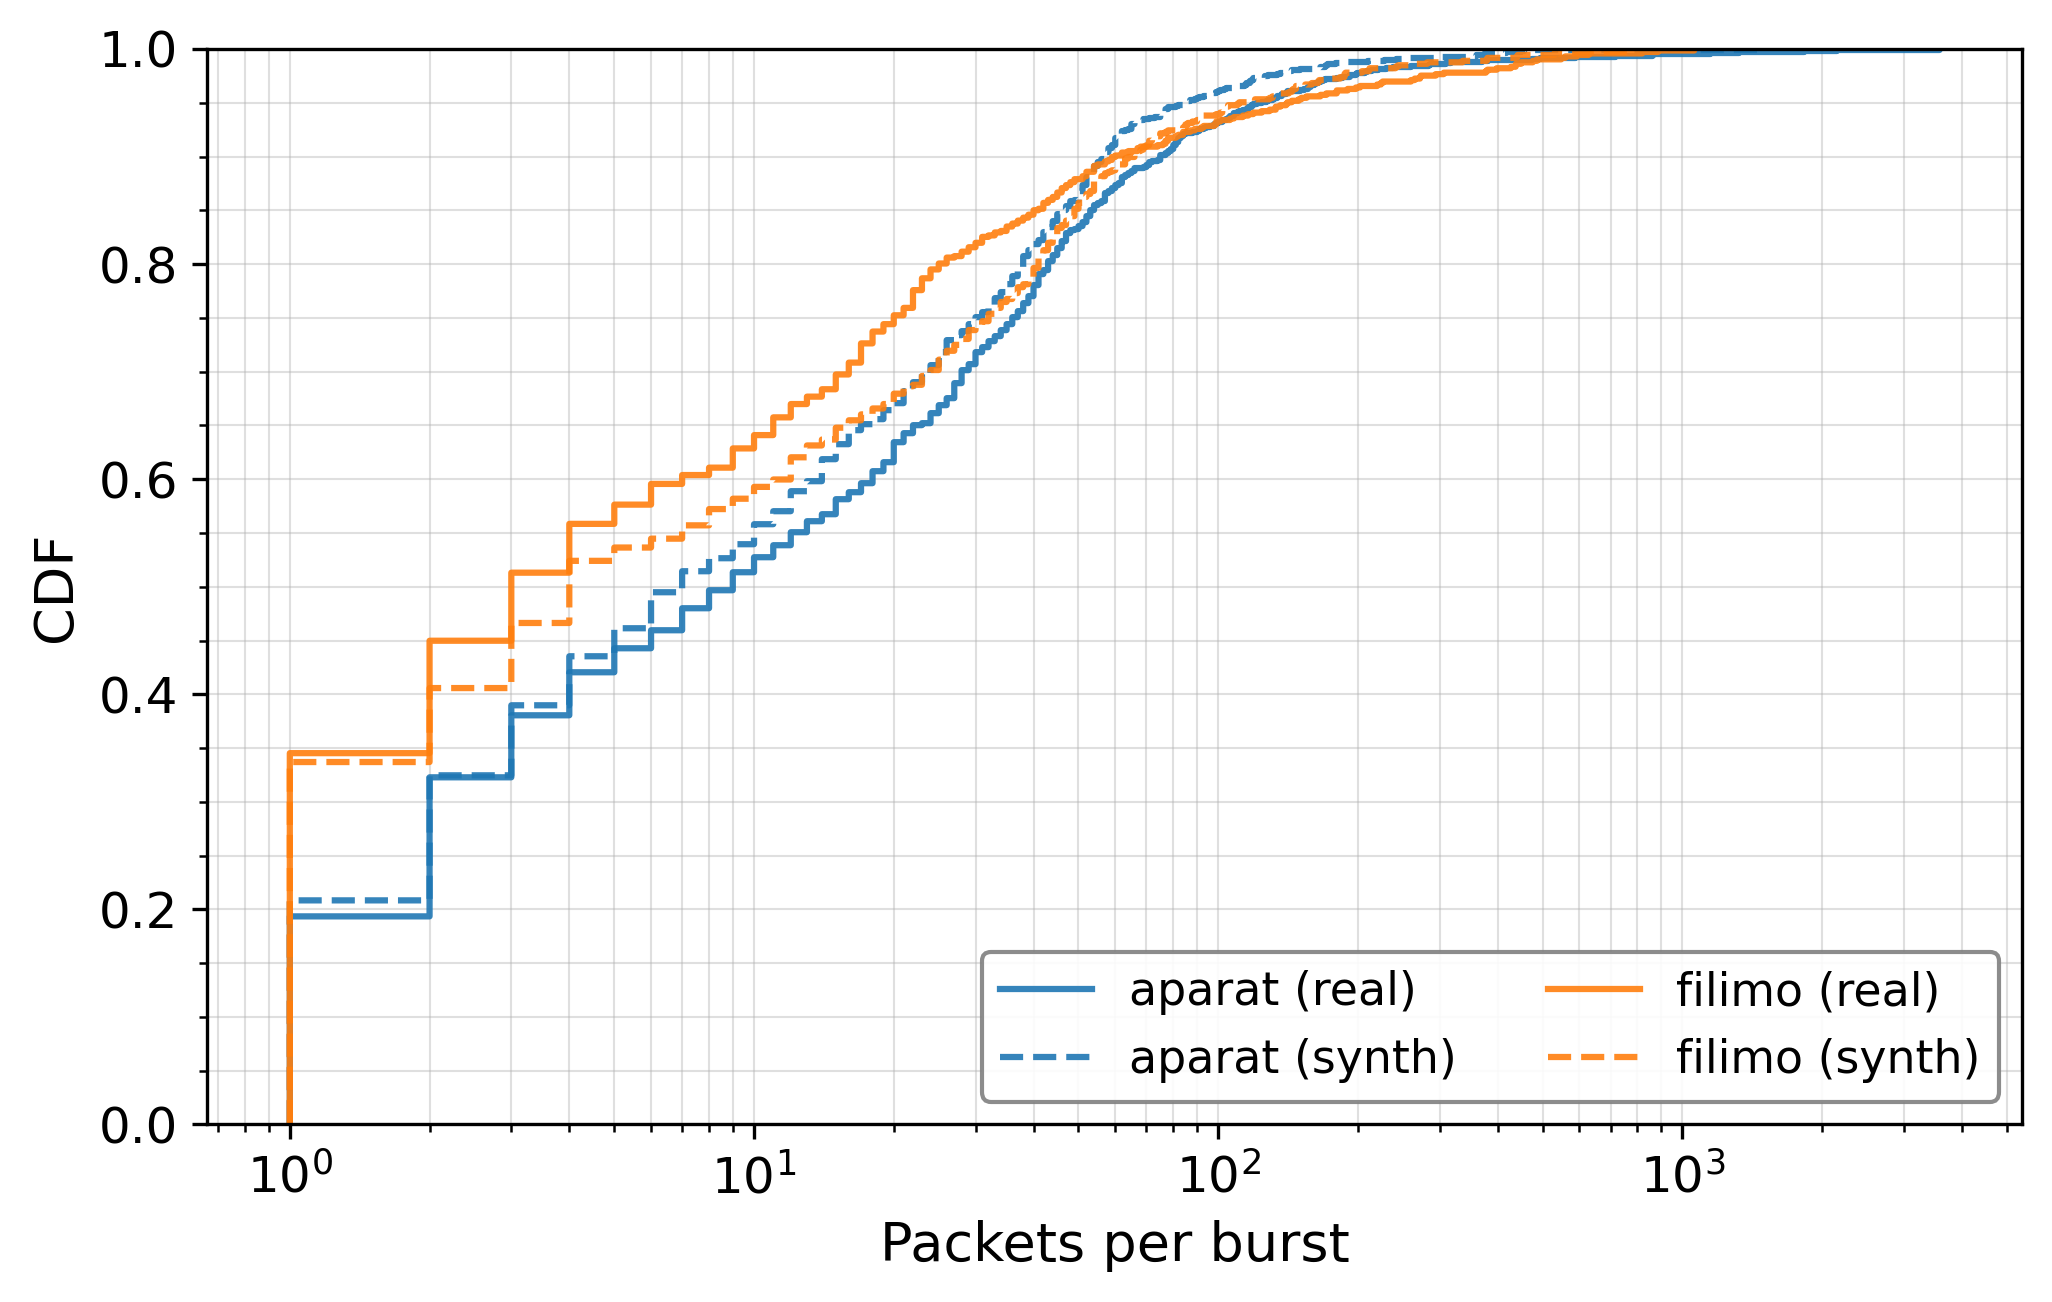


GENERATING STATISTICS TABLE


,Application,Feature,KS_Statistic,P_Value,Real_Mean,Synth_Mean,Relative_Error_%
0,aparat,Bytes per burst,0.0986,5.71e-05,55488.08,34827.38,-37.23
1,aparat,OFF duration (s),0.0720,0.0122,0.69,0.84,20.62
2,aparat,ON duration (s),0.0484,0.1616,0.05,0.03,-33.35
3,aparat,Packets per burst,0.0577,0.056,39.34,24.78,-37.01
4,filimo,Bytes per burst,0.1857,2.28e-11,44200.28,40199.11,-9.05
5,filimo,OFF duration (s),0.0748,0.0436,0.15,0.58,281.61
6,filimo,ON duration (s),0.0894,0.006,0.03,0.04,9.70
7,filimo,Packets per burst,0.0935,0.0034,31.31,28.54,-8.84



✅ Statistics saved to: ../comparison_figures/comparison_statistics_downlink.csv

ALL FIGURES GENERATED SUCCESSFULLY
Location: /Users/ghinwaismail/Desktop/trafficgen-paper/notebooks/../comparison_figures


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
from typing import List, Dict, Optional
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')


# Root directory where all artifacts are stored
ART_ROOT = Path("../artifacts")  

# Which apps to compare 
APPS_TO_COMPARE = ["aparat", "filimo"]  # "youtube", "telegram", "igap"

DIRECTION = "downlink"  

# Output directory for comparison figures

COMPARISON_DIR = Path("../comparison_figures")
COMPARISON_DIR.mkdir(exist_ok=True)

# Color and style configuration
APP_COLORS = {
    "aparat": "#1f77b4",    # blue
    "filimo": "#ff7f0e",    # orange  
    "youtube": "#2ca02c",   # green
    "telegram": "#d62728",  # red
    "igap": "#9467bd",      # purple
}

plt.rcParams['figure.dpi'] = 300  
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8

# Data Loading Functions

def find_latest_run_dir(app_dir: Path) -> Optional[Path]:
    """Find the most recent run directory for an app."""
    runs = sorted([p for p in app_dir.glob("run_*") if p.is_dir()])
    return runs[-1] if runs else None

def load_app_data(app: str, direction: str) -> Optional[Dict]:
    """Load real and synthetic test bursts for a specific app."""
    app_dir = ART_ROOT / app / direction
    if not app_dir.exists():
        print(f"⚠️  Directory not found: {app_dir}")
        return None
    
    run_dir = find_latest_run_dir(app_dir)
    if not run_dir:
        print(f"⚠️  No run directory found for {app}")
        return None
    
    data_dir = run_dir / "data"
    real_path = data_dir / "real_test_bursts.parquet"
    synth_path = data_dir / "synth_test_bursts_markov.parquet"
    
    try:
        if real_path.exists() and synth_path.exists():
            real_df = pd.read_parquet(real_path)
            synth_df = pd.read_parquet(synth_path)
        else:
            # Fallback: load from bursts_df with split
            bursts_path = run_dir / "bursts_df.parquet"
            if not bursts_path.exists():
                print(f"❌ No data found for {app}")
                return None
            bursts = pd.read_parquet(bursts_path)
            real_df = bursts[bursts["split"] == "test"] if "split" in bursts.columns else bursts
            synth_df = None  # Will skip synthetic for this app
            
        print(f"✅ {app}: {len(real_df)} real bursts loaded")
        
        return {
            "app": app,
            "real": real_df[["on_dur_s", "off_dur_s", "bytes", "packets"]],
            "synth": synth_df[["on_dur_s", "off_dur_s", "bytes", "packets"]] if synth_df is not None else None
        }
    except Exception as e:
        print(f"❌ Error loading {app}: {e}")
        return None

# Load all apps
    
print(f"Loading data from: {ART_ROOT}\n")
app_data = {}
for app in APPS_TO_COMPARE:
    data = load_app_data(app, DIRECTION)
    if data:
        app_data[app] = data

if not app_data:
    raise ValueError("No data loaded! Check paths and app names.")

# Plotting Functions

def ecdf(x: pd.Series):
    """Calculate Empirical CDF."""
    x = pd.to_numeric(x, errors="coerce").dropna().to_numpy()
    if x.size == 0:
        return np.array([]), np.array([])
    x_sorted = np.sort(x)
    y = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    return x_sorted, y

def create_single_feature_figure(app_data: Dict[str, Dict], 
                                feature: str, 
                                xlabel: str, 
                                title: str,
                                filename: str,
                                logx: bool = True,
                                figsize=(6, 4)):  
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot each app
    for app, data in app_data.items():
        color = APP_COLORS.get(app, None)
        
        # Real data - solid line
        
        real_vals = data["real"][feature]
        x_real, y_real = ecdf(real_vals)
        if len(x_real) > 0:
            ax.step(x_real, y_real, where="post", linestyle='-',
                   label=f"{app} (real)", color=color, alpha=0.9, linewidth=1.5)  
        
        # Synthetic data - dashed line
        
        if data["synth"] is not None:
            synth_vals = data["synth"][feature]
            x_synth, y_synth = ecdf(synth_vals)
            if len(x_synth) > 0:
                ax.step(x_synth, y_synth, where="post", linestyle='--',
                       label=f"{app} (synth)", color=color, alpha=0.9, linewidth=1.5)
    
    
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel("CDF", fontsize=13)
    ax.set_ylim(0, 1.0)
    ax.set_yticks(np.arange(0, 1.1, 0.2))  
    
   
    if logx:
        ax.set_xscale("log")
        ax.minorticks_on()  
        ax.grid(True, which="both", linestyle="-", linewidth=0.5, alpha=0.4)  
    else:
        ax.grid(True, which="both", linestyle="-", linewidth=0.5, alpha=0.4)
    

    ax.legend(loc='lower right', frameon=True, ncol=2, 
              fontsize=11, framealpha=0.9, edgecolor='gray')
    
    plt.tight_layout()
    

    base_path = COMPARISON_DIR / filename
    fig.savefig(base_path.with_suffix(".pdf"), bbox_inches="tight", dpi=300)
    fig.savefig(base_path.with_suffix(".png"), bbox_inches="tight", dpi=300)
    
    print(f"Saved: {base_path}.pdf")
    print(f"Saved: {base_path}.png")
    
    plt.show()
    plt.close(fig)
    
    return fig

# Generate Individual Figures

print("\n" + "="*60)
print("GENERATING INDIVIDUAL FEATURE FIGURES")
print("="*60 + "\n")

# Figure (a): Bytes per burst
create_single_feature_figure(
    app_data=app_data,
    feature="bytes",
    xlabel="Bytes per burst",
    title="Cumulative Distribution Function of the number of bytes per burst",
    filename=f"fig_3a_bytes_comparison_{DIRECTION}",
    logx=True,
    figsize=(7, 4.5)
)

# Figure (b): OFF duration
create_single_feature_figure(
    app_data=app_data,
    feature="off_dur_s",
    xlabel="OFF duration (s)",
    title="Cumulative Distribution Function of the OFF duration (i.e., inter-burst time)",
    filename=f"fig_3b_off_duration_comparison_{DIRECTION}",
    logx=True,
    figsize=(7, 4.5)
)

# Figure (c): ON duration  
create_single_feature_figure(
    app_data=app_data,
    feature="on_dur_s",
    xlabel="ON duration (s)",
    title="Cumulative Distribution Function of the ON duration (i.e., burst duration)",
    filename=f"fig_3c_on_duration_comparison_{DIRECTION}",
    logx=True,
    figsize=(7, 4.5)
)

# Figure (d): Packets per burst
create_single_feature_figure(
    app_data=app_data,
    feature="packets",
    xlabel="Packets per burst",
    title="Cumulative Distribution Function of the number of packets per burst",
    filename=f"fig_3d_packets_comparison_{DIRECTION}",
    logx=True,
    figsize=(7, 4.5)
)

# Generate Statistics Table

print("\n" + "="*60)
print("GENERATING STATISTICS TABLE")
print("="*60)

rows = []
features = [
    ("bytes", "Bytes per burst"),
    ("off_dur_s", "OFF duration (s)"),
    ("on_dur_s", "ON duration (s)"),
    ("packets", "Packets per burst")
]

for app, data in app_data.items():
    if data["synth"] is None:
        continue
        
    for feat_code, feat_name in features:
        real_vals = data["real"][feat_code].dropna()
        synth_vals = data["synth"][feat_code].dropna()
        
        if len(real_vals) > 0 and len(synth_vals) > 0:
            stat, p_val = ks_2samp(real_vals, synth_vals)
            rows.append({
                "Application": app,
                "Feature": feat_name,
                "KS_Statistic": round(stat, 4),
                "P_Value": f"{p_val:.2e}" if p_val < 0.001 else round(p_val, 4),
                "Real_Mean": round(real_vals.mean(), 2),
                "Synth_Mean": round(synth_vals.mean(), 2),
                "Relative_Error_%": round((synth_vals.mean() - real_vals.mean()) / real_vals.mean() * 100, 2)
            })

stats_df = pd.DataFrame(rows)
display(stats_df)

# Save statistics

stats_path = COMPARISON_DIR / f"comparison_statistics_{DIRECTION}.csv"
stats_df.to_csv(stats_path, index=False)
print(f"\n✅ Statistics saved to: {stats_path}")

print("\n" + "="*60)
print("ALL FIGURES GENERATED SUCCESSFULLY")
print(f"Location: {COMPARISON_DIR.absolute()}")
print("="*60)